In [ ]:
# - Import the pandas library for data manipulation
import pandas as pd


In [ ]:
# - Load the edge list for ego network 0
# Each row represents an anonymised pair of users who are connected (friends)
edges = pd.read_csv(
    "../facebook/0.edges",
    sep=" ",
    header=None,
    names=["source", "target"]
)

edges.head()

,source,target
0,236,186
1,122,285
2,24,346
3,271,304
4,176,9


In [ ]:
# - Display the first few rows of the dataset
edges.shape


(5038, 2)

In [ ]:
# - Explore the size of the network
# edges.shape returns a tuple: (number_of_rows, number_of_columns)
# Each row is one friendship (connection) between two anonymised users.
# This shows how many total connections exist in this ego network.
edges.shape


(5038, 2)

In [12]:
# — Count how many unique users exist
# The edges table has two columns: 'source' and 'target'.
# A user can appear in either column, so we combine both columns.
# pd.unique(...) finds all distinct user IDs.
# len(nodes) shows how many unique users are present in this ego network.
nodes = pd.unique(edges[["source", "target"]].values.ravel())
len(nodes)


333

In [13]:
# — Find the most connected users
# To find how many connections each user has, the code combines counts how often each user ID appears.
# A user can appear in 'source' or 'target', the code combines both columns.
# value_counts() shows a list of users sorted by number of connections (degree).
# degree.head(10) shows the top 10 most connected users in this ego network.
degree = pd.concat([edges["source"], edges["target"]]).value_counts()
degree.head(10)


56     154
67     150
271    144
322    142
25     136
26     134
252    128
21     128
277    128
122    124
Name: count, dtype: int64

In [17]:
# — Create a NetworkX graph from the edges data
# NetworkX is a library used to analyse networks (graphs).
# The code creates an empty graph object called G.
# Then it adds all the friendship pairs (source → target) as edges in the graph.
# After this step, G becomes a full network structure that NetworkX can analyse.
import networkx as nx

G = nx.from_pandas_edgelist(edges, source="source", target="target")


In [15]:
G = nx.from_pandas_edgelist(edges, source="source", target="target")


In [18]:
# — Calculate basic graph statistics
# G.number_of_nodes() shows how many unique users are in the network.
# G.number_of_edges() shows how many friendship connections exist.
# nx.degree(G) gives the number of connections each user has.
# max(dict(nx.degree(G)).values()) finds the highest degree (most connected user).
# These statistics help us understand the size and structure of the network.
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
degrees = dict(G.degree())
max_degree = max(degrees.values())

num_nodes, num_edges, max_degree


(333, 2519, 77)

Matplotlib is building the font cache; this may take a moment.


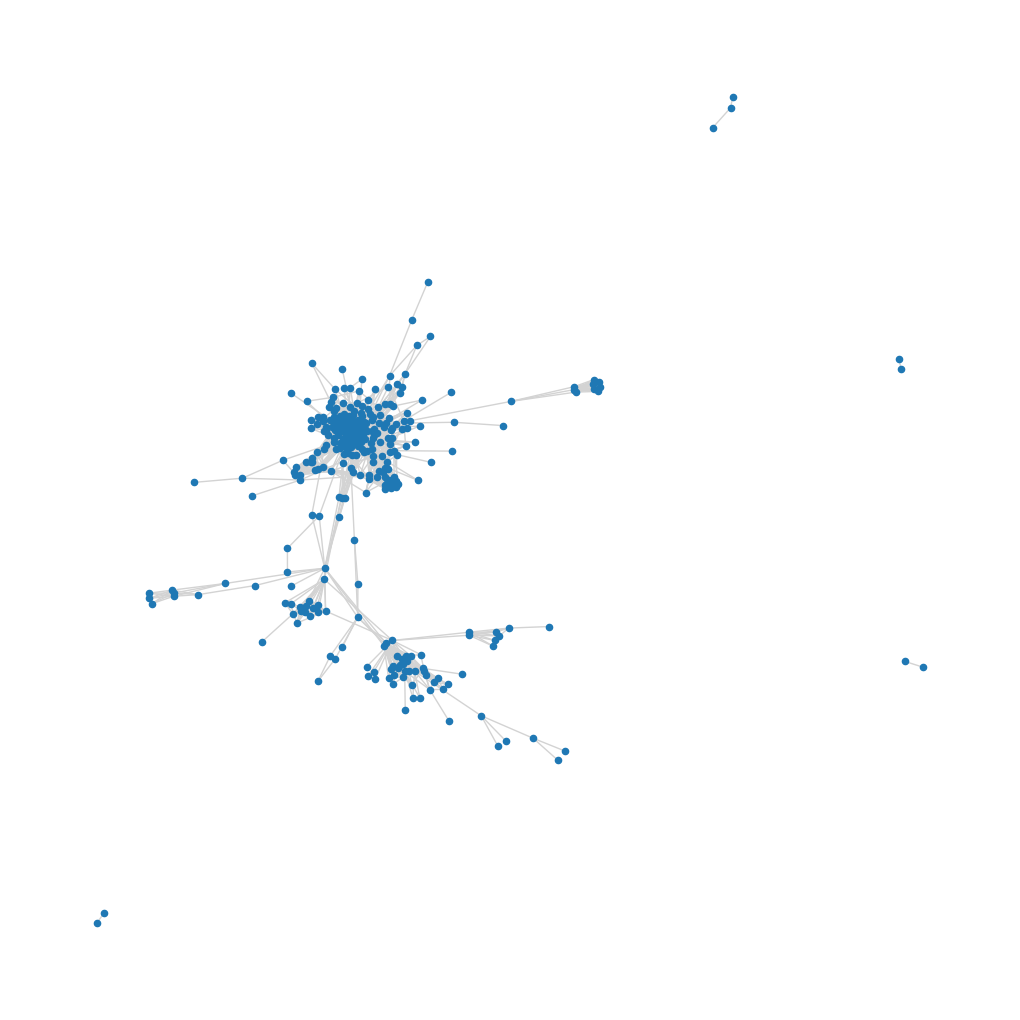

In [20]:
# — Visualise the network using NetworkX
# nx.spring_layout(G) calculates positions for each node so the graph looks readable.
# plt.figure() creates a blank canvas for the plot.
# nx.draw() draws the nodes and edges of the network.
# node_size controls how big each user appears.
# edge_color sets the colour of the connections.
# This visualisation helps us see the structure of the ego network.
import matplotlib.pyplot as plt

pos = nx.spring_layout(G)
plt.figure(figsize=(10, 10))
nx.draw(G, pos, node_size=20, edge_color="lightgray")
plt.show()


In [21]:
# — Descriptive statistics for the ego network

# Number of nodes (unique users)
num_nodes = G.number_of_nodes()

# Number of edges (friendship connections)
num_edges = G.number_of_edges()

# Average degree (average number of connections per user)
avg_degree = sum(dict(G.degree()).values()) / num_nodes

# Median degree
import numpy as np
median_degree = np.median(list(dict(G.degree()).values()))

# Degree distribution (list of all degrees)
degree_values = list(dict(G.degree()).values())

# Number of connected components
num_components = nx.number_connected_components(G)

# Size of the largest connected component
largest_component = max(nx.connected_components(G), key=len)
largest_component_size = len(largest_component)

num_nodes, num_edges, avg_degree, median_degree, num_components, largest_component_size


(333, 2519, 15.12912912912913, np.float64(10.0), 5, 324)

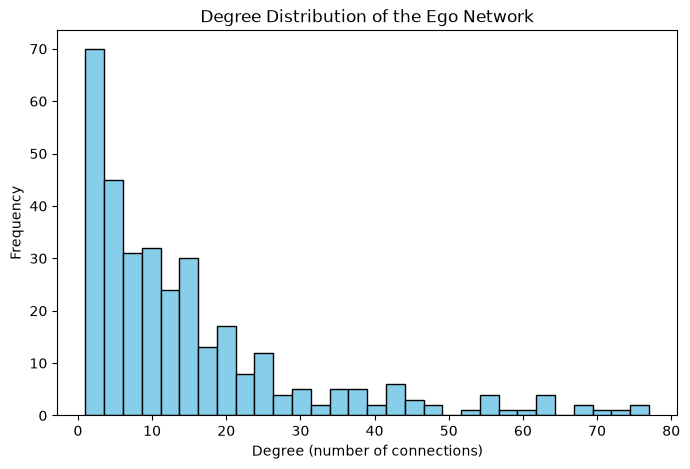

In [22]:
# — Degree distribution histogram

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(degree_values, bins=30, color="skyblue", edgecolor="black")
plt.title("Degree Distribution of the Ego Network")
plt.xlabel("Degree (number of connections)")
plt.ylabel("Frequency")
plt.show()


In [23]:
# — Centrality Measures for the Ego Network

# Degree centrality: users with the most direct connections
degree_centrality = nx.degree_centrality(G)

# Betweenness centrality: users who act as bridges between groups
betweenness_centrality = nx.betweenness_centrality(G)

# Closeness centrality: users closest to all others in terms of distance
closeness_centrality = nx.closeness_centrality(G)

# Eigenvector centrality: users connected to other influential users
eigenvector_centrality = nx.eigenvector_centrality(G)

# Show top 10 for each measure
import pandas as pd

centrality_df = pd.DataFrame({
    "degree": degree_centrality,
    "betweenness": betweenness_centrality,
    "closeness": closeness_centrality,
    "eigenvector": eigenvector_centrality
})

centrality_df.sort_values("degree", ascending=False).head(10)


,degree,betweenness,closeness,eigenvector
56,0.231928,0.019714,0.369264,0.198145
67,0.225904,0.017708,0.372327,0.197438
271,0.216867,0.014974,0.368399,0.193678
322,0.213855,0.043159,0.376340,0.159753
25,0.204819,0.085363,0.380902,0.154776
26,0.201807,0.009570,0.364552,0.186401
21,0.192771,0.033100,0.365400,0.160469
277,0.192771,0.265858,0.413479,0.162030
252,0.192771,0.010658,0.361200,0.177161
122,0.186747,0.022754,0.362868,0.165014
